In [1]:
import Pkg; Pkg.activate(".")
using CairoMakie

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`


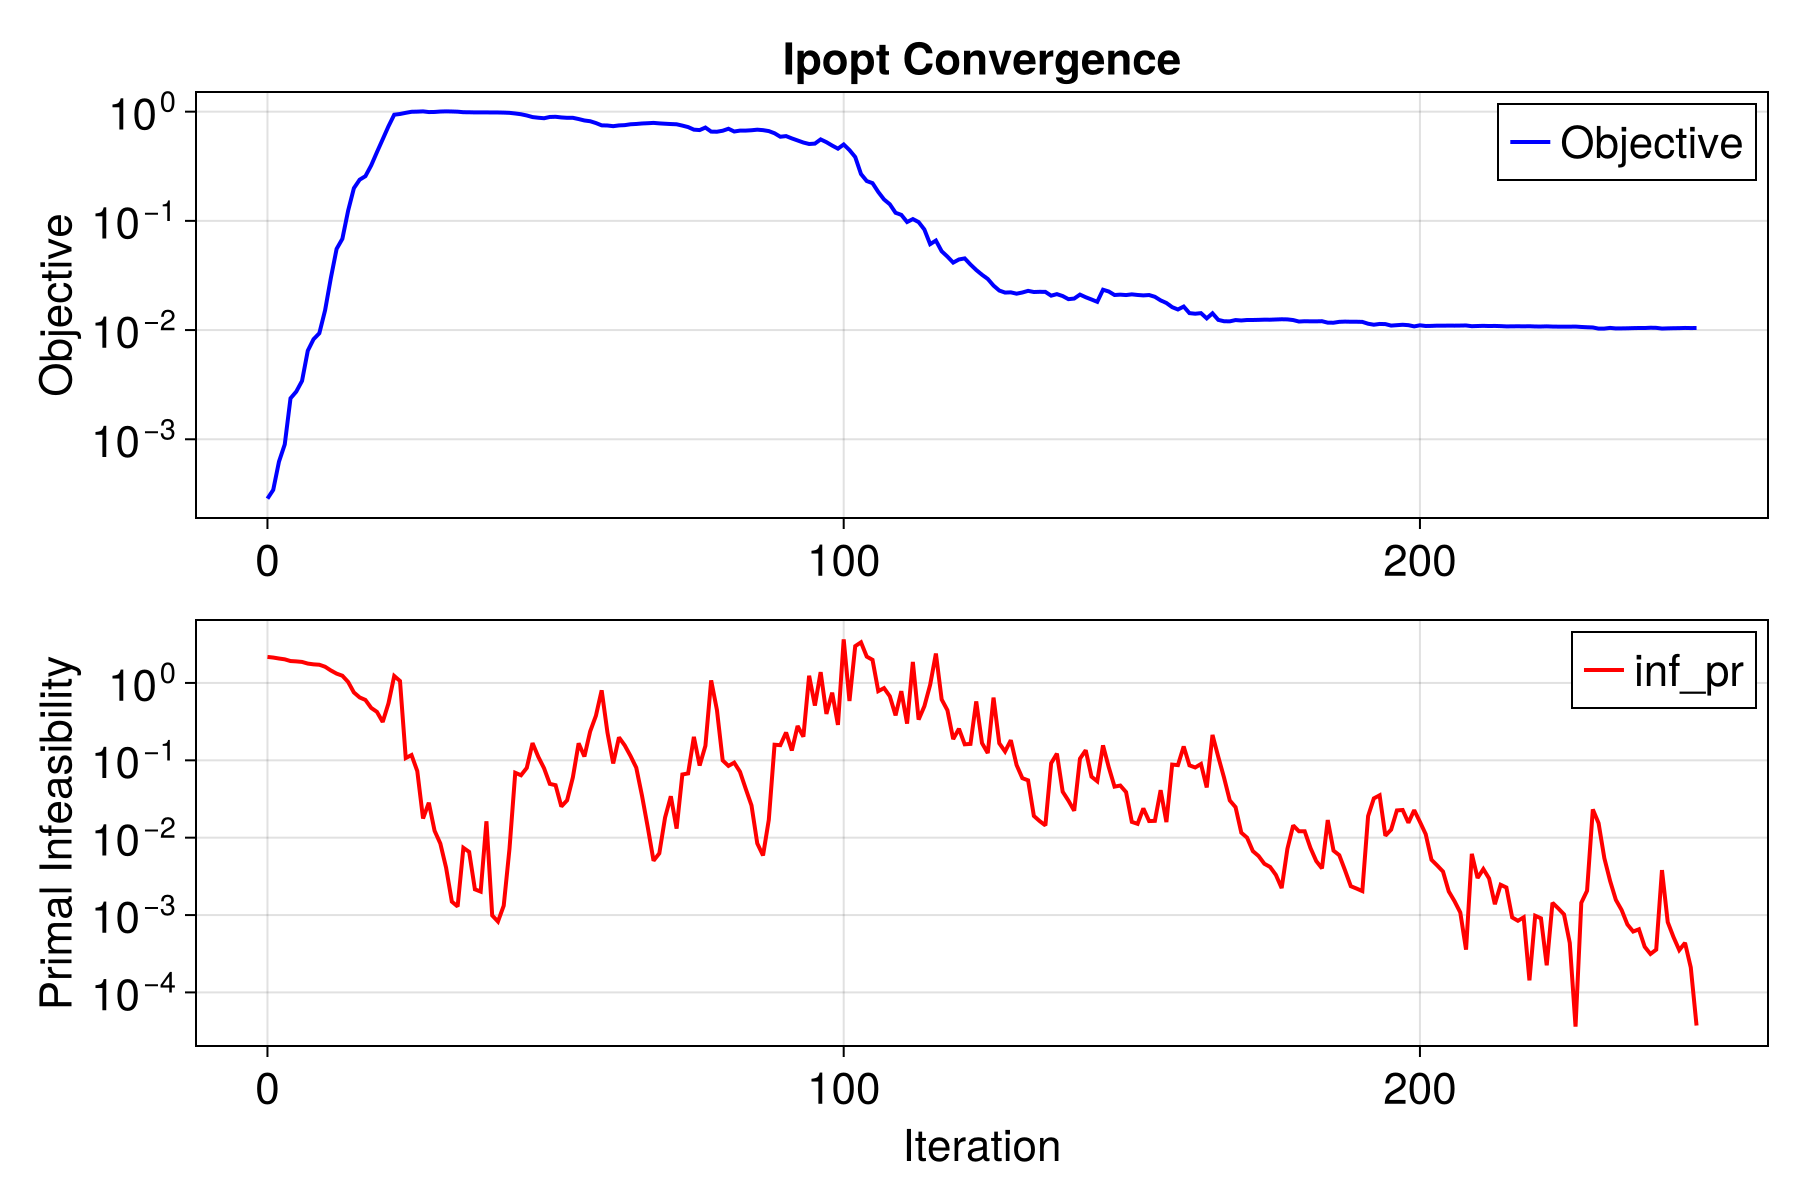

Iterations: 249
Final objective: 0.010440446 at iteration 248
Final inf_pr: 3.73e-5


In [2]:
# Parse Ipopt log and plot objective vs iteration
log_path = "ipopt_robust_iswap_detuned_24knots.log"
lines_log = readlines(log_path)

iters = Int[]
objs = Float64[]
inf_prs = Float64[]

for line in lines_log
    m = match(r"^\s*(\d+)\s+([\d.e+\-]+)\s+([\d.e+\-]+)", line)
    if m !== nothing
        push!(iters, parse(Int, m.captures[1]))
        push!(objs, parse(Float64, m.captures[2]))
        push!(inf_prs, parse(Float64, m.captures[3]))
    end
end

fig = Figure(fontsize=22, size=(900, 600))

ax1 = Axis(fig[1, 1], ylabel="Objective", title="Ipopt Convergence", yscale=log10)
lines!(ax1, iters, objs; linewidth=2, color=:blue, label="Objective")
axislegend(ax1, position=:rt)

ax2 = Axis(fig[2, 1], xlabel="Iteration", ylabel="Primal Infeasibility", yscale=log10)
lines!(ax2, iters, inf_prs; linewidth=2, color=:red, label="inf_pr")
axislegend(ax2, position=:rt)

linkxaxes!(ax1, ax2)
display(fig)

println("Iterations: ", length(iters))
println("Final objective: ", objs[end], " at iteration ", iters[end])
println("Final inf_pr: ", inf_prs[end])

In [6]:
# Parse Ipopt log and plot objective vs iteration
log_path = "ipopt_robust_iswap_detuned.log"
lines_log = readlines(log_path)

iters = Int[]
objs = Float64[]
inf_prs = Float64[]

for line in lines_log
    m = match(r"^\s*(\d+)\s+([\d.e+\-]+)\s+([\d.e+\-]+)", line)
    if m !== nothing
        push!(iters, parse(Int, m.captures[1]))
        push!(objs, parse(Float64, m.captures[2]))
        push!(inf_prs, parse(Float64, m.captures[3]))
    end
end

fig = Figure(fontsize=22, size=(900, 600))

ax1 = Axis(fig[1, 1], ylabel="Objective", title="Ipopt Convergence", yscale=log10)
lines!(ax1, iters, objs; linewidth=2, color=:blue, label="Objective")
axislegend(ax1, position=:lt)

ax2 = Axis(fig[2, 1], xlabel="Iteration", ylabel="Primal Infeasibility", yscale=log10)
lines!(ax2, iters, inf_prs; linewidth=2, color=:red, label="inf_pr")
axislegend(ax2, position=:lt)

linkxaxes!(ax1, ax2)
display(fig)

println("Iterations: ", length(iters))
println("Final objective: ", objs[end], " at iteration ", iters[end])
println("Final inf_pr: ", inf_prs[end])

Iterations: 144
Final objective: 0.04385793 at iteration 143
Final inf_pr: 0.211


In [4]:
using GLMakie                                                                                                                                                                                                                                                                                                             
  GLMakie.activate!()                                                                                                                                                                                                                                                                                                     

  iters_obs   = Observable(Int[])                                                                                                                                                                                                                                                                                           
  objs_obs    = Observable(Float64[])
  inf_prs_obs = Observable(Float64[])                                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                          
  fig = Figure(fontsize=22, size=(900, 600))
  ax1 = Axis(fig[1, 1], ylabel="Objective", yscale=log10, title="Ipopt Convergence")
  lines!(ax1, iters_obs, objs_obs; color=:blue)                                                                                                                                                                                                                                                                             
  ax2 = Axis(fig[2, 1], xlabel="Iteration", ylabel="Primal Infeasibility", yscale=log10)                                                                                                                                                                                                                                    
  lines!(ax2, iters_obs, inf_prs_obs; color=:red)                                                                                                                                                                                                                                                                           
  linkxaxes!(ax1, ax2)                                                                                                                                                                                                                                                                                                      
  display(fig)                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                            
  log_path = "ipopt_robust_iswap_detuned.log"                                                                                                                                                                                                                                                                               
  @async while isopen(fig.scene)
      try                                                                                                                                                                                                                                                                                                                   
          i, o, p = parse_ipopt_log(log_path)                                                                                                                                                                                                                                                                             
          if !isempty(i)
              iters_obs[]   = i
              objs_obs[]    = o                                                                                                                                                                                                                                                                                             
              inf_prs_obs[] = p
              autolimits!(ax1); autolimits!(ax2)                                                                                                                                                                                                                                                                            
          end                                                                                                                                                                                                                                                                                                             
      catch e
          @warn "refresh failed" exception=e
      end                                                                                                                                                                                                                                                                                                                   
      sleep(2.0)
  end            

┌ Warning: refresh failed
│   exception = UndefVarError(:parse_ipopt_log, Main)
└ @ Main /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:27


Task (runnable, started) @0x0000000345e85dc0